# Tarefa: Análise Descritiva e Visualização de Dados

**Aluno:** Cauê Reis

**Disciplina:** Mineração de Dados

## Dataset Bank Marketing — Medidas Descritivas e Visualizações

**Objetivo:** Aplicar análise descritiva (medidas de tendência central e de dispersão) sobre 3 atributos numéricos do dataset Bank Marketing e gerar 3 tipos de visualização (Boxplot, Histograma + KDE e Gráfico de Barras), interpretando a presença de outliers e comparando a variabilidade entre os atributos.

### 1. Importações e Carregamento dos Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('bank.csv', sep=';')

print('Primeiras observacoes do dataset:')
display(df.head(10))

print(f'\nDimensoes: {df.shape[0]} amostras x {df.shape[1]} atributos')
print(f'Atributos numericos: {list(df.select_dtypes(include="number").columns)}')
print(f'\nDistribuicao da variavel-alvo (y):')
print(df['y'].value_counts())

Primeiras observacoes do dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no



Dimensoes: 4521 amostras x 17 atributos
Atributos numericos: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Distribuicao da variavel-alvo (y):
y
no     4000
yes     521
Name: count, dtype: int64


### 2. Análise Descritiva — Medidas de Tendência Central e Dispersão

Os 3 atributos selecionados para análise são:
- **`age`** — idade do cliente (anos)
- **`balance`** — saldo médio anual na conta (euros)
- **`duration`** — duração do último contato telefônico (segundos)

In [4]:
atributos = ['age', 'balance', 'duration']
labels    = ['Idade (anos)', 'Saldo médio anual (€)', 'Duração do contato (s)']

display(df[atributos].describe().round(3))

,age,balance,duration
count,4521.000,4521.000,4521.000
mean,41.170,1422.658,263.961
std,10.576,3009.638,259.857
min,19.000,-3313.000,4.000
25%,33.000,69.000,104.000
50%,39.000,444.000,185.000
75%,49.000,1480.000,329.000
max,87.000,71188.000,3025.000


In [5]:
rows = []
for col, label in zip(atributos, labels):
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    out_n = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
    rows.append({
        'Atributo'     : label,
        'Média'        : round(s.mean(), 2),
        'Mediana'      : round(s.median(), 2),
        'Moda'         : round(s.mode()[0], 2),
        'Desvio Padrão': round(s.std(), 2),
        'Variância'    : round(s.var(), 2),
        'CV (%)'       : round(s.std() / s.mean() * 100, 1),
        'IQR'          : round(iqr, 2),
        'Outliers (IQR)': out_n
    })

df_stats = pd.DataFrame(rows)
display(df_stats.set_index('Atributo'))

,Média,Mediana,Moda,Desvio Padrão,Variância,CV (%),IQR,Outliers (IQR)
Atributo,,,,,,,,
Idade (anos),41.17,39.0,34,10.58,111.86,25.7,16.0,38
Saldo médio anual (€),1422.66,444.0,0,3009.64,9057921.75,211.6,1411.0,506
Duração do contato (s),263.96,185.0,123,259.86,67525.47,98.4,225.0,330


### 3. Visualização 1 — Boxplots: Detecção de Outliers

O boxplot exibe de forma compacta a mediana, os quartis (Q1 e Q3) e os outliers (pontos além de 1,5× o IQR). A linha tracejada vermelha indica a **média**, que se afasta da mediana quando há assimetria — sinal clássico de outliers puxando a distribuição.

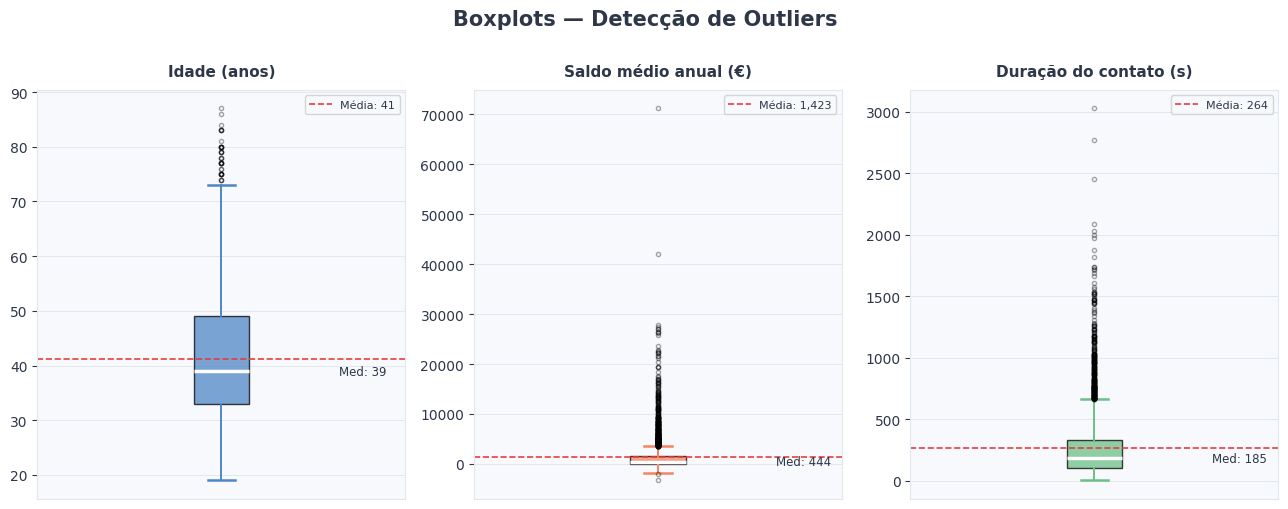

In [6]:
C1, C2, C3 = '#4F86C6', '#F4845F', '#6DBF87'
cores = [C1, C2, C3]
BG, GRID, TEXT = '#F7F9FC', '#E2E8F0', '#2D3748'

plt.rcParams.update({
    'axes.facecolor': BG, 'figure.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.7,
})

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Boxplots — Detecção de Outliers', fontsize=15, fontweight='bold', y=1.01)

for ax, col, label, cor in zip(axes, atributos, labels, cores):
    data = df[col]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    flierprops=dict(marker='o', color=cor, alpha=0.35, markersize=3),
                    whiskerprops=dict(color=cor, linewidth=1.4),
                    capprops=dict(color=cor, linewidth=1.8))
    bp['boxes'][0].set_facecolor(cor)
    bp['boxes'][0].set_alpha(0.75)
    ax.set_title(label, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks([])
    med = data.median()
    ax.axhline(data.mean(), color='#E53E3E', linestyle='--', linewidth=1.2,
               label=f'Média: {data.mean():,.0f}')
    ax.text(1.32, med, f'Med: {med:,.0f}', va='center', fontsize=8.5, color=TEXT)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### 4. Visualização 2 — Histogramas com Curva KDE

O histograma mostra a frequência de cada faixa de valores. A curva **KDE** (*Kernel Density Estimation*) suaviza essa distribuição, revelando o formato geral. Quando **média > mediana**, a distribuição é **assimétrica à direita** — característica comum em dados financeiros e de duração.

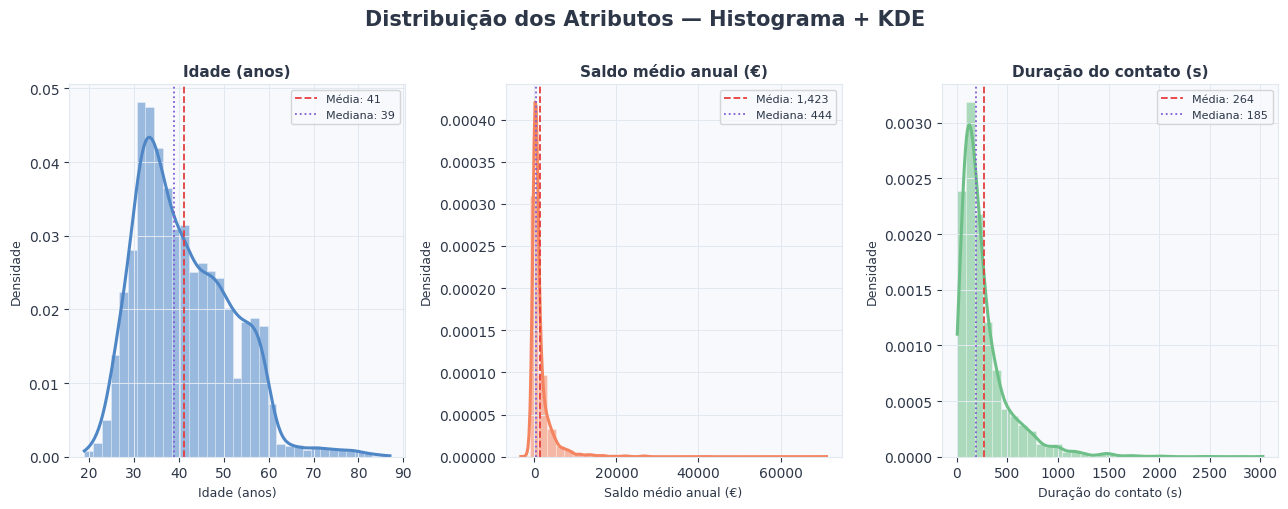

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Distribuição dos Atributos — Histograma + KDE',
             fontsize=15, fontweight='bold', y=1.01)

for ax, col, label, cor in zip(axes, atributos, labels, cores):
    data = df[col]
    ax.hist(data, bins=35, color=cor, alpha=0.55, edgecolor='white',
            linewidth=0.4, density=True)
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=cor, linewidth=2.2)
    ax.axvline(data.mean(),   color='#E53E3E', linestyle='--', linewidth=1.3,
               label=f'Média: {data.mean():,.0f}')
    ax.axvline(data.median(), color='#805AD5', linestyle=':',  linewidth=1.3,
               label=f'Mediana: {data.median():,.0f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5. Visualização 3 — Taxa de Subscrição por Profissão

O gráfico de barras exibe a **proporção de clientes que aderiram ao depósito a prazo** (`y = 'yes'`) em cada categoria de profissão (`job`). Barras em azul escuro indicam profissões acima da média geral.

C:\Users\cauer\AppData\Local\Temp\ipykernel_25224\2950944388.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(job_rate['job'], rotation=35, ha='right', fontsize=9)


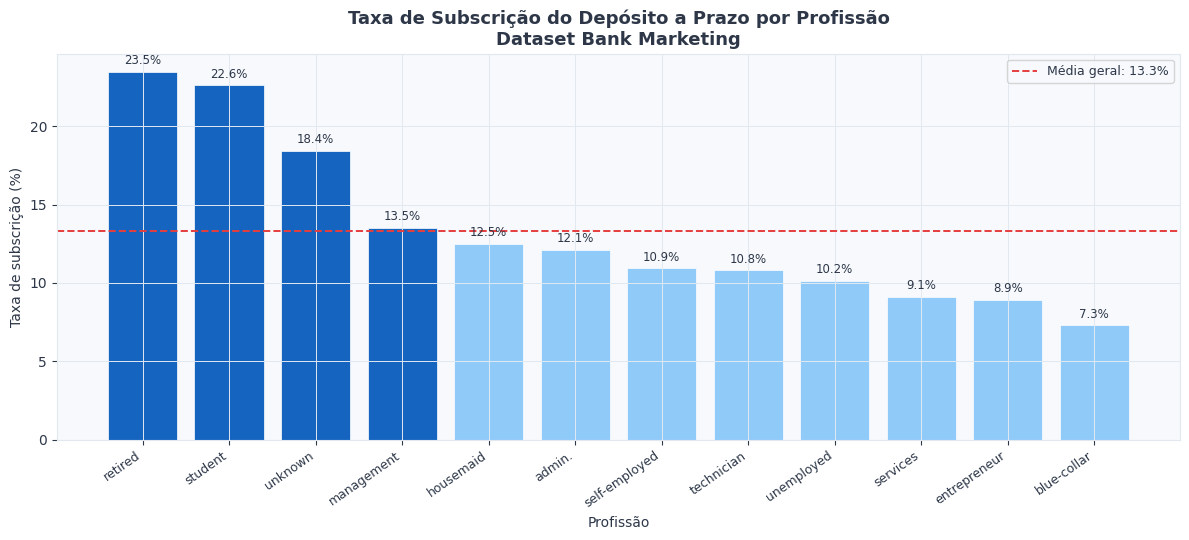

In [8]:
job_rate = (
    df.groupby('job')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=False)
      .reset_index()
)
job_rate.columns = ['job', 'taxa']

media_geral = job_rate['taxa'].mean()
cores_bar = ['#1565C0' if t >= media_geral else '#90CAF9' for t in job_rate['taxa']]

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(job_rate['job'], job_rate['taxa'],
              color=cores_bar, edgecolor='white', linewidth=0.5)

ax.axhline(media_geral, color='#E53E3E', linestyle='--', linewidth=1.4,
           label=f'Média geral: {media_geral:.1f}%')

for bar, val in zip(bars, job_rate['taxa']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Profissão', fontsize=10)
ax.set_ylabel('Taxa de subscrição (%)', fontsize=10)
ax.set_title('Taxa de Subscrição do Depósito a Prazo por Profissão\n'
             'Dataset Bank Marketing', fontsize=13, fontweight='bold')
ax.set_xticklabels(job_rate['job'], rotation=35, ha='right', fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6. Interpretação dos Resultados

#### Há Outliers?

Sim, os três atributos apresentam outliers identificados pelo critério de Tukey (1,5 × IQR), porém com intensidades muito diferentes:

- **`balance` (Saldo)** — caso mais crítico: **506 outliers**. O dataset contém clientes com saldo negativo (até −€3.313) e casos extremos de até €71.188, indicando grande heterogeneidade financeira entre os clientes. O boxplot evidencia essa assimetria com uma longa cauda superior e pontos dispersos bem acima do bigode.

- **`duration` (Duração)** — **330 outliers**. A maioria dos contatos dura menos de 6 minutos (mediana = 185 s), mas alguns ultrapassam 50 minutos. Esses casos extremos representam interações atípicas e provavelmente bem-sucedidas.

- **`age` (Idade)** — apenas **38 outliers**, correspondendo a clientes com idades elevadas (acima de ~70 anos). A distribuição de idade é a mais comportada das três.

#### Qual Variável Apresenta Maior Variabilidade?

O **Coeficiente de Variação (CV)** é a métrica mais adequada para comparar variabilidade entre atributos em escalas diferentes, pois é adimensional (desvio padrão relativo à média):

| Atributo | Média | Desvio Padrão | CV (%) |
|---|---|---|---|
| Idade | 41,17 | 10,58 | 25,7% |
| Duração | 263,96 | 259,86 | 98,4% |
| **Saldo** | **1.422,66** | **3.009,64** | **211,6%** |

**`balance`** é, de longe, o atributo com maior variabilidade (CV = 211,6%). Um CV superior a 100% indica que o desvio padrão é maior que a própria média, refletindo uma distribuição extremamente heterogênea — há clientes com saldo zero ou negativo e outros com fortunas consideráveis no banco.

`duration` também apresenta alta variabilidade (CV ≈ 98,4%), sugerindo que a duração do contato varia enormemente dependendo do perfil e da receptividade do cliente.

`age` é a variável mais homogênea (CV = 25,7%), o que faz sentido: a base de clientes de um banco tende a se concentrar em faixas etárias ativas (30–55 anos), sem extremos muito acentuados.

#### Sobre os Histogramas

Nos três atributos, **média > mediana**, confirmando distribuições assimétricas à direita. Isso é característico de variáveis que têm limite inferior (não podem ser negativas ou muito baixas) mas não têm limite superior bem definido. Os outliers de alto valor 'puxam' a média para cima, enquanto a mediana permanece mais próxima do centro real da distribuição.

#### Sobre o Gráfico de Barras

**Estudantes** e **aposentados** apresentam as maiores taxas de adesão ao depósito a prazo, sugerindo que esses grupos têm maior disponibilidade financeira ou motivação para investimentos de longo prazo. **Operários (blue-collar)** e funcionários de **serviços** ficam consistentemente abaixo da média, o que pode orientar estratégias de segmentação em futuras campanhas.

### 7. Conclusão

A análise descritiva do dataset **Bank Marketing** revelou insights importantes sobre a distribuição dos dados e a heterogeneidade da base de clientes:

- As três variáveis analisadas possuem distribuições **assimétricas à direita**, com presença confirmada de outliers em todas elas. O atributo `balance` concentra os casos mais extremos (506 outliers), refletindo a alta desigualdade de renda entre clientes.

- **`balance`** é a variável de maior variabilidade absoluta e relativa (CV = 211,6%), o que exige atenção especial em algoritmos sensíveis à escala, como K-Means, KNN e SVM. A normalização ou padronização é essencial antes de qualquer modelagem.

- O gráfico de barras confirma que o perfil profissional do cliente impacta significativamente a propensão à adesão ao produto, com estudantes e aposentados liderando e operários ficando abaixo da média — informação útil para segmentação de campanhas.

- A discrepância entre média e mediana em todos os atributos reforça que a **mediana** é uma medida de tendência central mais robusta do que a média para esses dados, pois não é distorcida pelos valores extremos.